# 05 — Linear Regression → Logistic Regression → Neural Networks
## Machine Learning in SPM Tutorial
*RMS AFM & SPM Meeting 2026*

## Goals

By the end of this notebook you will be able to:

- Understand **linear regression** — fitting a straight line to predict a continuous number
- Apply it to a real SPM problem: extracting Young's modulus from a force–distance curve via Hertzian contact mechanics
- Understand **logistic regression** — extending linear regression to predict a *class* using the sigmoid function
- Explain why logistic regression is mathematically identical to **one artificial neuron**, setting up neural networks in the next notebook

## What is regression — and how does it connect to classification?

**Linear regression** learns a function that maps inputs to a **continuous output** by fitting a straight line (or hyperplane):

$$\hat{y} = \mathbf{w} \cdot \mathbf{x} + b$$

In SPM this is everywhere: extracting stiffness or modulus from force curves, calibrating InvOLS, predicting a material property from a spectrum.

**Logistic regression** makes one small change — it wraps the linear combination in a **sigmoid** function:

$$\hat{y} = \sigma(\mathbf{w} \cdot \mathbf{x} + b), \qquad \sigma(z) = \frac{1}{1+e^{-z}}$$

This squashes the output into $[0, 1]$, turning it into a probability. Now the model predicts a class instead of a number. And crucially: **that sigmoid-wrapped linear combination is exactly one artificial neuron** — the atom out of which neural networks are built.

In [1]:
# --- Colab bootstrap: clone the repo & install deps when running on Google Colab ---
# (Does nothing when you run locally from the cloned repo.)
import os, sys
if 'google.colab' in sys.modules:
    if not os.path.exists('RMS-AFM-SPM-Meeting-2026'):
        !git clone -q https://github.com/Liambcollins/RMS-AFM-SPM-Meeting-2026.git
    %cd RMS-AFM-SPM-Meeting-2026/notebooks
    !pip -q install scikit-image >/dev/null 2>&1
    print('Colab setup complete.')

In [2]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
import numpy as np
import matplotlib.pyplot as plt
from viz.plotting import set_style
set_style()
print("Setup complete.")
from synthetic.generators import make_fd_curve, make_scan_quality_dataset

Setup complete.


## Part 1 — Linear regression on a force–distance curve

A force–distance curve has a flat pre-contact region, then rises as the tip indents the surface.
For a spherical tip on a soft sample, **Hertzian contact mechanics** predicts

$$F = \tfrac{4}{3}\,E^{*}\sqrt{R}\;\delta^{3/2}$$

where $\delta$ is the indentation depth. If we use $\delta^{3/2}$ as our input feature, the
relationship becomes **linear** — so ordinary linear regression recovers the effective modulus $E^{*}$.

In [3]:
z_nm, force_nn, meta = make_fd_curve(E_modulus_kpa=150.0, random_state=1)

contact = z_nm > 0                       # indentation regime
delta = np.clip(z_nm, 0, None)
feature = (delta ** 1.5).reshape(-1, 1)  # delta^(3/2) -> linear in F

from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(feature[contact], force_nn[contact])
force_fit = reg.predict(feature)
print(f"Fitted slope (proportional to E*): {reg.coef_[0]:.4f} nN / nm^1.5")

Fitted slope (proportional to E*): 0.0013 nN / nm^1.5


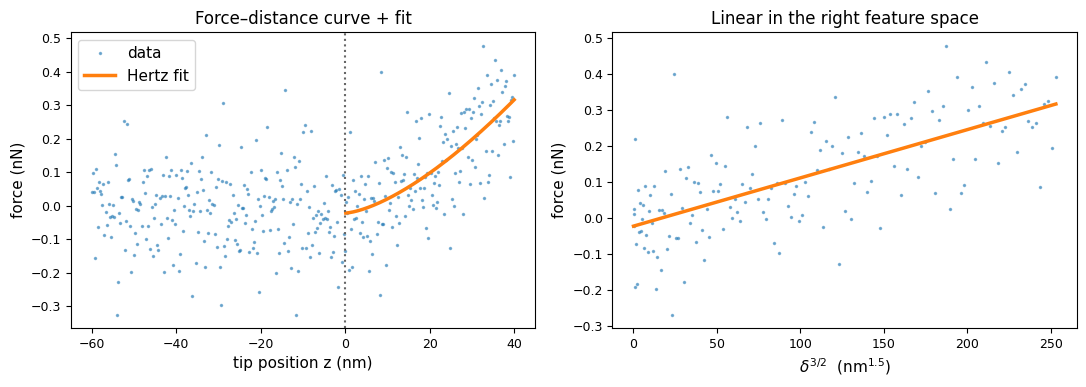

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(z_nm, force_nn, '.', ms=3, alpha=0.5, label='data')
ax[0].plot(z_nm[contact], force_fit[contact], 'C1', lw=2.5, label='Hertz fit')
ax[0].axvline(0, color='0.4', ls=':'); ax[0].set_xlabel('tip position z (nm)')
ax[0].set_ylabel('force (nN)'); ax[0].set_title('Force–distance curve + fit'); ax[0].legend()
ax[1].plot(feature[contact], force_nn[contact], '.', ms=3, alpha=0.5)
ax[1].plot(feature[contact], force_fit[contact], 'C1', lw=2.5)
ax[1].set_xlabel(r'$\delta^{3/2}$  (nm$^{1.5}$)'); ax[1].set_ylabel('force (nN)')
ax[1].set_title('Linear in the right feature space')
fig.tight_layout(); plt.show()

**Takeaway:** choosing the right *feature* (here $\delta^{3/2}$) turns a non-linear physics problem
into a one-line linear fit. Feature engineering guided by physics is one of the most powerful tricks in SPM ML.

## Part 2 — Logistic Regression and the single neuron

In SPM we often need to make a **binary decision**: is this scan usable or corrupted? Is this pixel in contact or not?

Logistic regression handles this by passing the familiar linear combination through a sigmoid. The sigmoid has three useful properties:
- It is bounded between 0 and 1 (interpretable as a probability)
- It is smooth and differentiable everywhere (important for training)
- Its midpoint is at $z = 0$ — values above the decision boundary map to $> 0.5$, values below to $< 0.5$

Here we will classify **scan quality**: given two features extracted from an SPM image (line-to-line noise and feature contrast), predict whether a scan is good or bad.

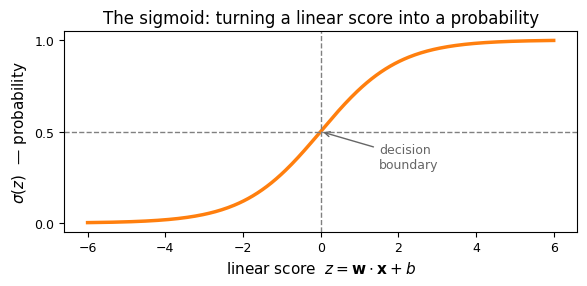

Features: ['line_noise', 'feature_contrast']
Class counts: [300 300]  (0 = good scan, 1 = bad scan)


In [5]:
# Plot the sigmoid function
z = np.linspace(-6, 6, 300)
sigma = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(z, sigma, 'C1', lw=2.5)
ax.axhline(0.5, color='0.5', ls='--', lw=1)
ax.axvline(0.0, color='0.5', ls='--', lw=1)
ax.set_xlabel('linear score  $z = \\mathbf{w}\\cdot\\mathbf{x} + b$')
ax.set_ylabel('$\\sigma(z)$  — probability')
ax.set_title('The sigmoid: turning a linear score into a probability')
ax.set_yticks([0, 0.5, 1])
ax.annotate('decision\nboundary', xy=(0, 0.5), xytext=(1.5, 0.3),
            arrowprops=dict(arrowstyle='->', color='0.4'), color='0.4', fontsize=9)
plt.tight_layout(); plt.show()

# Load synthetic scan-quality dataset (2 features for easy visualisation)
X2, _, y, feat_names = make_scan_quality_dataset(n_samples=600, random_state=42)
print("Features:", feat_names[:2])
print("Class counts:", np.bincount(y), " (0 = good scan, 1 = bad scan)")

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_tr, X_te, y_tr, y_te = train_test_split(X2, y, test_size=0.25, random_state=0)
clf = LogisticRegression(max_iter=500).fit(X_tr, y_tr)
pred = clf.predict(X_te)

print(f"Accuracy: {accuracy_score(y_te, pred):.3f}\n")
print(classification_report(y_te, pred, target_names=['good', 'bad']))

Accuracy: 0.953

              precision    recall  f1-score   support

        good       0.92      1.00      0.96        81
         bad       1.00      0.90      0.95        69

    accuracy                           0.95       150
   macro avg       0.96      0.95      0.95       150
weighted avg       0.96      0.95      0.95       150



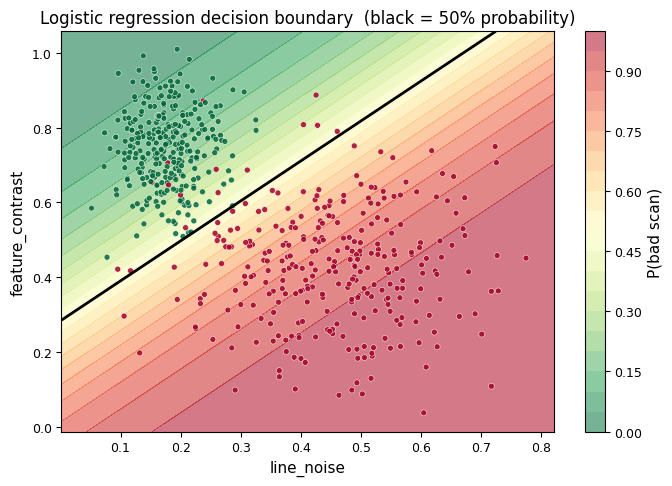

In [7]:
# Decision boundary: colour the feature space by P(bad scan)
h = 0.005
x0, x1 = X2[:, 0].min() - 0.05, X2[:, 0].max() + 0.05
y0, y1 = X2[:, 1].min() - 0.05, X2[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.arange(x0, x1, h), np.arange(y0, y1, h))
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn_r', alpha=0.55, vmin=0, vmax=1)
plt.colorbar(cf, ax=ax, label='P(bad scan)')
ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap='RdYlGn_r', vmin=0, vmax=1,
           edgecolors='white', linewidths=0.4, s=18, alpha=0.85)
ax.set_xlabel(feat_names[0]); ax.set_ylabel(feat_names[1])
ax.set_title('Logistic regression decision boundary  (black = 50% probability)')
plt.tight_layout(); plt.show()

## Bonus — Logistic regression: the bridge to neural networks

Everything above predicted a *number*. **Logistic regression** adapts the same linear machinery to predict a
*probability* — and in doing so it becomes the single most important stepping stone to deep learning.

The recipe is just two steps:

1. Compute a weighted sum of the inputs, exactly like linear regression: $z = w \cdot x + b$
2. Squash it through the **sigmoid** $\sigma(z) = 1/(1+e^{-z})$ so the output lands in $[0, 1]$ — a probability.

That combination — *weighted sum → non-linear activation* — **is one artificial neuron.** Logistic regression is
literally a one-neuron neural network. Stack many of these neurons into layers and you have the multilayer
perceptron in notebook 07. So if you understand this slide, you already understand the building block of deep learning.

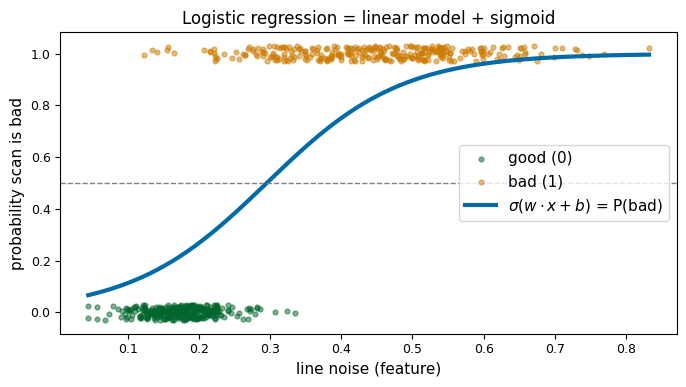

Decision threshold at P=0.5; train accuracy = 0.94


In [8]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from synthetic.generators import make_scan_quality_dataset

# One feature (line-noise) -> probability the scan is 'bad'
_, X4, y, names = make_scan_quality_dataset(n_samples=600, random_state=1)
x = X4[:, 0].reshape(-1, 1)                    # line_noise
clf = LogisticRegression().fit(x, y)

grid = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
prob = clf.predict_proba(grid)[:, 1]          # P(bad)

fig, ax = plt.subplots(figsize=(7, 4))
jitter = (np.random.default_rng(0).random(len(y)) - 0.5) * 0.06
ax.scatter(x[y==0, 0], 0*y[y==0] + jitter[y==0], s=12, color='#00662C', alpha=0.5, label='good (0)')
ax.scatter(x[y==1, 0], 1+0*y[y==1] + jitter[y==1], s=12, color='#CC7A00', alpha=0.5, label='bad (1)')
ax.plot(grid, prob, color='#006BA6', lw=3, label=r'$\sigma(w\cdot x + b)$ = P(bad)')
ax.axhline(0.5, color='0.5', ls='--', lw=1)
ax.set_xlabel('line noise (feature)'); ax.set_ylabel('probability scan is bad')
ax.set_title('Logistic regression = linear model + sigmoid'); ax.legend(loc='center right')
fig.tight_layout(); plt.show()

print(f"Decision threshold at P=0.5; train accuracy = {clf.score(x, y):.2f}")

## Takeaways — and the road to neural networks

| Model | Predicts | Formula |
|---|---|---|
| Linear regression | a number | $\hat{y} = \mathbf{w}\cdot\mathbf{x} + b$ |
| Logistic regression | a probability / class | $\hat{y} = \sigma(\mathbf{w}\cdot\mathbf{x} + b)$ |
| Neural network (1 hidden layer) | anything | $\hat{y} = \sigma\!\left(\mathbf{W}_2\,\sigma(\mathbf{W}_1\mathbf{x}+\mathbf{b}_1)+\mathbf{b}_2\right)$ |

**The key insight:** a logistic regression unit *is* one artificial neuron — a linear combination followed by a non-linear activation (sigmoid). A neural network is simply many such neurons stacked in layers. Adding layers lets the model learn curved, non-linear decision boundaries that a single logistic unit cannot.

The decision boundary above is a straight line because logistic regression has only one layer. In the next notebook we will add hidden layers and watch the boundary become arbitrarily complex — same building block, more of them.